In [20]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.io import wavfile
from scipy.signal import get_window
import scipy.fftpack as fft

In [21]:
TRAIN_PATH = './sample.wav' # Audio masih stereo / 2 channel
sample_rate, audio = wavfile.read(TRAIN_PATH)
audio = audio.mean(axis=1)

C:\Users\prk\AppData\Local\Temp\ipykernel_3036\3081188426.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio = wavfile.read(TRAIN_PATH)


In [22]:
audio

array([-0.5,  1.5, -2.5, ...,  0. , -1. ,  1.5])

In [23]:
sample_rate

44100

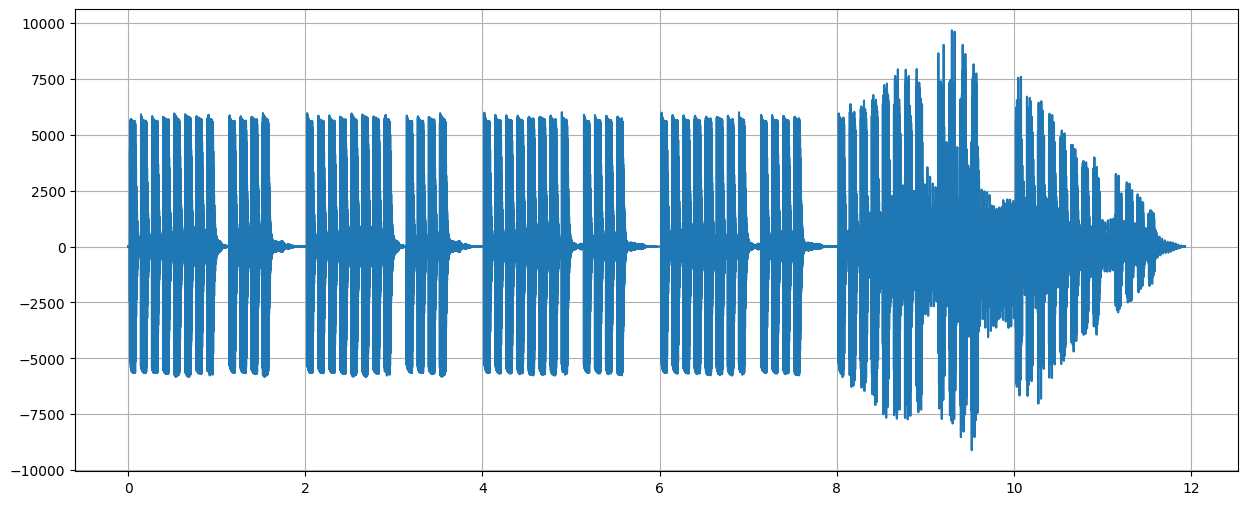

In [24]:
plt.figure(figsize=(15,6))
plt.plot(np.linspace(0, len(audio)/sample_rate, len(audio)), audio)
plt.grid(True)

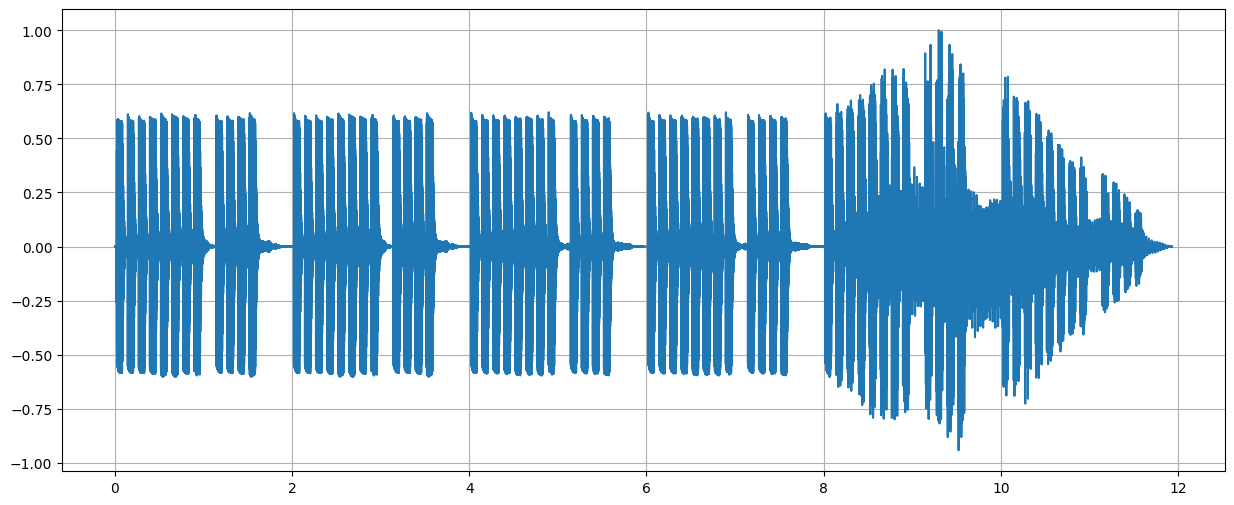

In [25]:
# Normalization -> value amplitudo menjadi range -1 sampai 1
audio = audio / np.abs(np.max(audio))

plt.figure(figsize=(15,6))
plt.plot(np.linspace(0, len(audio)/sample_rate, len(audio)), audio)
plt.grid(True)

In [26]:
# Frame Blocking -> bagi audio menjadi beberapa chunks
# Audio -> freq berubah (non stasioner)

FFT_SIZE = 2048 # per chunk ambil 2048 samples
HOP_SIZE = 15 # 15 ms

# Tambahin padding ke audio supaya windowing tidak rusak
audio = np.pad(audio, int(FFT_SIZE / 2), mode="reflect")
# hop length -> jarak per hop
frame_len = np.round(sample_rate * HOP_SIZE / 1000).astype(int)
frame_num = ((len(audio) - FFT_SIZE) // frame_len) + 1

print(frame_len)
print(frame_num)

662
795


In [27]:
frames = np.zeros((frame_num, FFT_SIZE))

for i in range(frame_num):
    frames[i] = audio[i * frame_len : i * frame_len + FFT_SIZE]

In [28]:
# Windowing => Kasih efek fade in & fade out di semua chunk
window = get_window("hann", FFT_SIZE, fftbins=True)
audio_win = frames * window

Text(0.5, 1.0, 'Window Audio - After')

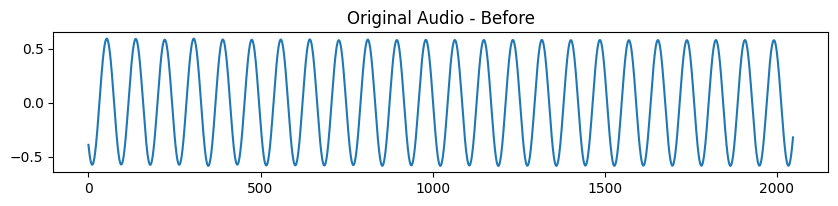

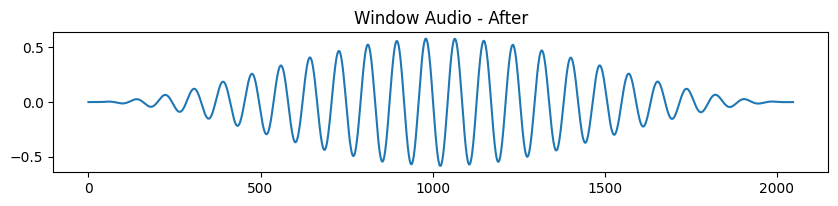

In [32]:
index = 20
plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(frames[index])
plt.title("Original Audio - Before")

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 2)
plt.plot(audio_win[index])
plt.title("Window Audio - After")

In [44]:
# Fast Fourier Transform => audio dari time domain jadi frequency domain
# x jadi frequency, y jadi strength audio
print(audio_win.shape)

audio_winT = np.transpose(audio_win)
print(audio_winT.shape)
audio_fft = np.empty((1 + FFT_SIZE // 2, audio_winT.shape[1]), dtype=np.complex64, order="F")
print(audio_fft.shape)

for i in range(audio_fft.shape[1]):
    audio_fft[:, i] = fft.fft(audio_winT[:, i], axis = 0)[:audio_fft.shape[0]]

audio_fft = np.transpose(audio_fft)
audio_power = np.square(np.abs(audio_fft))

print(audio_power)

(795, 2048)
(2048, 795)
(1025, 795)
[[7.60837972e-01 3.91881287e-01 3.52898409e-04 ... 2.32163038e-05
  1.31043576e-04 3.27309914e-04]
 [1.16151514e+01 2.48543301e+01 4.34041367e+01 ... 7.11474277e-05
  5.70396442e-05 5.14762942e-05]
 [1.19168495e+02 9.06343842e+01 3.51294365e+01 ... 2.25715165e-04
  8.40079811e-05 3.61013808e-05]
 ...
 [3.49409655e-02 2.24569783e-01 7.72094548e-01 ... 1.61517295e-04
  3.26933805e-04 2.34656036e-04]
 [2.08988767e-02 7.66787231e-02 2.61905100e-02 ... 1.52380089e-04
  8.63082914e-06 4.13344381e-08]
 [7.70598743e-03 1.76128373e-02 4.08387743e-02 ... 1.08224689e-04
  4.08310962e-06 5.51167614e-06]]
